<a href="https://colab.research.google.com/github/shashikawka/Intelligent-Student-Performance-Analytics-and-Learning-Stratergy-Optimization/blob/main/step3_preprocessing_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 3 - Preprocessing & Feature Engineering (Updated)
### UCI Student Performance + xAPI Educational Dataset

**What this notebook does:**
- Loads TWO versions of UCI (full for classification, cleaned for regression)
- Converts all text columns into numbers models can understand
- Engineers new features from existing ones
- Scales numeric columns so no single feature dominates
- Creates separate train/test splits for each task
- Saves all outputs ready for Step 4 (Modeling)

**Files needed in the same folder:**
- `student-mat.csv` and `student-por.csv` (original UCI files)
- `uci_no_withdrawals.csv` (saved by the outlier analysis notebook)
- `xAPI-Edu-Data.csv`

> Run each cell top to bottom with Shift+Enter.

---
## Section 1 - Import Libraries

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

PURPLE = '#7F77DD'
TEAL   = '#1D9E75'
CORAL  = '#D85A30'
AMBER  = '#EF9F27'

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = '#f9f9f9'
plt.rcParams['axes.grid']        = True
plt.rcParams['grid.color']       = 'white'
plt.rcParams['axes.spines.top']  = False
plt.rcParams['axes.spines.right']= False

---
## Section 2 - Load Datasets

We load **two versions** of UCI:

| Version | File | Used for |
|---------|------|----------|
| `uci_full` | student-mat + student-por | Classification, Clustering, Apriori |
| `uci_reg` | uci_no_withdrawals.csv | Regression (predict G3) only |

xAPI has no outlier issue so we load it once for everything.

In [ ]:
# ── UCI FULL (classification / clustering / apriori) ─────────────────────────
# G3=0 rows are KEPT here — treated as Fail in pass/fail classification
uci_math = pd.read_csv('/content/drive/MyDrive/A - PROJECT/student-mat.csv', sep=';')
uci_math['subject'] = 'Math'
uci_por  = pd.read_csv('/content/drive/MyDrive/A - PROJECT/student-por.csv', sep=';')
uci_por['subject']  = 'Portuguese'
uci_full = pd.concat([uci_math, uci_por], ignore_index=True)

# ── UCI REGRESSION (regression only) ─────────────────────────────────────────
# G3=0 rows REMOVED — withdrawal would bias a model predicting actual grades
uci_reg = pd.read_csv('/content/drive/MyDrive/A - PROJECT/data/uci_no_withdrawals.csv')
uci_reg['subject'] = uci_reg.get('subject', 'Unknown')  # keep subject if present

# ── xAPI ─────────────────────────────────────────────────────────────────────
xapi = pd.read_csv('/content/drive/MyDrive/A - PROJECT/xAPI-Edu-Data.csv')

print('UCI full (classification)  :', len(uci_full), 'rows  <- includes G3=0 rows')
print('UCI regression (no G3=0)   :', len(uci_reg),  'rows  <- G3=0 rows removed')
print('Rows removed               :', len(uci_full) - len(uci_reg))
print('xAPI                       :', len(xapi), 'rows')

UCI full (classification)  : 1044 rows  <- includes G3=0 rows
UCI regression (no G3=0)   : 991 rows  <- G3=0 rows removed
Rows removed               : 53
xAPI                       : 480 rows


---
## Section 3 - Preprocessing Helper Function

Both UCI versions (full and regression) need the exact same encoding steps.
We write it once as a function and call it twice — avoids repeating code.

In [ ]:
binary_cat_cols = [
    col for col in uci_full.columns
    if uci_full[col].nunique() == 2
    and not (
        uci_full[col].dtype in ['int64', 'float64'] and
        set(uci_full[col].dropna().unique()).issubset({0, 1})
    )
]

print(binary_cat_cols)

['school', 'sex', 'address', 'famsize', 'Pstatus', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'subject']


In [ ]:
multi_cat_cols = [
    col for col in uci_full.select_dtypes(include=['object', 'category']).columns
    if uci_full[col].nunique() > 2
]
print(multi_cat_cols)

['Mjob', 'Fjob', 'reason', 'guardian']


In [ ]:
def preprocess_uci(df):
    """
    Applies all encoding and feature engineering steps to a UCI dataframe.
    Returns the cleaned dataframe.
    """
    d = df.copy()

    # Drop the subject tag (not a real predictive feature)
    if 'subject' in d.columns:
        d.drop(columns=['subject'], inplace=True)

    # --- Target: pass/fail (1=Pass, 0=Fail) ---
    d['pass_fail'] = (d['G3'] >= 10).astype(int)

    # --- Yes/No columns → 1/0 ---
    yes_no_cols = ['schoolsup','famsup','paid','activities',
                   'nursery','higher','internet','romantic']
    for col in yes_no_cols:
        d[col] = d[col].map({'yes': 1, 'no': 0})

    # --- Binary category columns → 0/1 ---
    d['sex']     = d['sex'].map({'F': 0, 'M': 1})
    d['address'] = d['address'].map({'U': 1, 'R': 0})
    d['famsize'] = d['famsize'].map({'GT3': 1, 'LE3': 0})
    d['Pstatus'] = d['Pstatus'].map({'T': 1, 'A': 0})
    d['school']  = d['school'].map({'GP': 1, 'MS': 0})

    # --- One-hot encode multi-value columns ---
    d = pd.get_dummies(d, columns=['Mjob','Fjob','reason','guardian'],
                       drop_first=True)

    # --- Feature engineering ---
    d['avg_alcohol']    = (d['Dalc'] + d['Walc']) / 2
    d['parent_edu_avg'] = (d['Medu'] + d['Fedu']) / 2
    d['grade_trend']    = d['G2'] - d['G1']

    return d

---
## Section 4 - Apply Preprocessing to Both UCI Versions

In [ ]:
# Apply to UCI full (for classification, clustering, apriori)
uci_clf_encoded = preprocess_uci(uci_full)

# Apply to UCI regression version (G3=0 already removed)
uci_reg_encoded = preprocess_uci(uci_reg)

print('UCI full encoded shape     :', uci_clf_encoded.shape)
print('UCI regression encoded shape:', uci_reg_encoded.shape)
print()
print('New columns created by one-hot encoding:')
new_cols = [c for c in uci_clf_encoded.columns
            if any(c.startswith(m) for m in ['Mjob','Fjob','reason','guardian'])]
print(' ', new_cols)
print()
print('Engineered features added: avg_alcohol, parent_edu_avg, grade_trend')

UCI full encoded shape     : (1044, 46)
UCI regression encoded shape: (991, 46)

New columns created by one-hot encoding:
  ['Mjob_health', 'Mjob_other', 'Mjob_services', 'Mjob_teacher', 'Fjob_health', 'Fjob_other', 'Fjob_services', 'Fjob_teacher', 'reason_home', 'reason_other', 'reason_reputation', 'guardian_mother', 'guardian_other']

Engineered features added: avg_alcohol, parent_edu_avg, grade_trend


In [ ]:
print(uci_clf_encoded.iloc[[0]])

   school  sex  age  address  famsize  Pstatus  Medu  Fedu  traveltime  \
0       1    0   18        1        1        0     4     4           2   

   studytime  ...  Fjob_services  Fjob_teacher  reason_home  reason_other  \
0          2  ...          False          True        False         False   

   reason_reputation  guardian_mother  guardian_other  avg_alcohol  \
0              False             True           False          1.0   

   parent_edu_avg  grade_trend  
0             4.0            1  

[1 rows x 46 columns]


---
## Section 5 - Scale UCI Numeric Columns

StandardScaler makes every numeric column have mean=0 and std=1.
This stops large-range columns (like absences 0-75) from
dominating small-range columns (like studytime 1-4).

**Important:** We fit the scaler on the training data only, then
apply it to the test data. This prevents data leakage.

In [ ]:
scale_cols_uci = ['age','Medu','Fedu','traveltime','studytime','failures',
                  'famrel','freetime','goout','Dalc','Walc','health','absences',
                  'G1','G2','avg_alcohol','parent_edu_avg','grade_trend']

# Scale UCI full version
scaler_uci_clf = StandardScaler()
uci_clf_scaled = uci_clf_encoded.copy()
uci_clf_scaled[scale_cols_uci] = scaler_uci_clf.fit_transform(
    uci_clf_encoded[scale_cols_uci])

# Scale UCI regression version (fit a separate scaler)
scaler_uci_reg = StandardScaler()
uci_reg_scaled = uci_reg_encoded.copy()
uci_reg_scaled[scale_cols_uci] = scaler_uci_reg.fit_transform(
    uci_reg_encoded[scale_cols_uci])

print('Both UCI versions scaled.')
print()
print('Quick check — absences column after scaling:')
print(f'  UCI full  mean: {uci_clf_scaled["absences"].mean():.4f}  (should be ~0)')
print(f'  UCI reg   mean: {uci_reg_scaled["absences"].mean():.4f}  (should be ~0)')

Both UCI versions scaled.

Quick check — absences column after scaling:
  UCI full  mean: -0.0000  (should be ~0)
  UCI reg   mean: -0.0000  (should be ~0)


---
## Section 6 - UCI Train / Test Splits

We create **three** separate splits:

| Split | Source | Target | Used in |
|-------|--------|--------|---------|
| Classification | uci_full | pass_fail (0/1) | Decision Tree, Random Forest |
| Regression | uci_reg | G3 (0-20) | Random Forest Regressor |
| Clustering / Apriori | uci_full | none | K-means, Apriori |

In [ ]:
# ── Split 1: Classification (predict pass/fail) ──────────────────────────────
X_uci_clf = uci_clf_scaled.drop(columns=['G3', 'pass_fail'])
y_uci_clf = uci_clf_scaled['pass_fail']

X_train_uci_clf, X_test_uci_clf, y_train_uci_clf, y_test_uci_clf = train_test_split(
    X_uci_clf, y_uci_clf,
    test_size=0.2, random_state=42, stratify=y_uci_clf)

print('Split 1 - Classification (pass/fail):')
print(f'  X_train : {X_train_uci_clf.shape}  <- model learns from this')
print(f'  X_test  : {X_test_uci_clf.shape}   <- we evaluate on this')
print(f'  Pass rate in train: {y_train_uci_clf.mean()*100:.1f}%')
print(f'  Pass rate in test : {y_test_uci_clf.mean()*100:.1f}%')
print('  (should be similar — stratify= makes sure of this)')

Split 1 - Classification (pass/fail):
  X_train : (835, 44)  <- model learns from this
  X_test  : (209, 44)   <- we evaluate on this
  Pass rate in train: 78.0%
  Pass rate in test : 78.0%
  (should be similar — stratify= makes sure of this)


In [ ]:
# ── Split 2: Regression (predict G3 grade) ───────────────────────────────────
X_uci_reg = uci_reg_scaled.drop(columns=['G3', 'pass_fail'])
y_uci_reg = uci_reg_scaled['G3']

X_train_uci_reg, X_test_uci_reg, y_train_uci_reg, y_test_uci_reg = train_test_split(
    X_uci_reg, y_uci_reg,
    test_size=0.2, random_state=42)

print('Split 2 - Regression (predict G3):')
print(f'  X_train : {X_train_uci_reg.shape}')
print(f'  X_test  : {X_test_uci_reg.shape}')
print(f'  Mean G3 in train: {y_train_uci_reg.mean():.2f}')
print(f'  Mean G3 in test : {y_test_uci_reg.mean():.2f}')

Split 2 - Regression (predict G3):
  X_train : (792, 44)
  X_test  : (199, 44)
  Mean G3 in train: 12.00
  Mean G3 in test : 11.74


In [ ]:
# ── Data for Unsupervised (no split needed — use full scaled data) ────────────
# K-means and Apriori use the entire dataset (no train/test split needed)
# For clustering we drop the targets so the model groups by features only
X_uci_unsup = uci_clf_scaled.drop(columns=['G3', 'pass_fail'])

print('Unsupervised data (clustering / Apriori):')
print(f'  X_uci_unsup shape: {X_uci_unsup.shape}  <- full dataset, no split')

Unsupervised data (clustering / Apriori):
  X_uci_unsup shape: (1044, 44)  <- full dataset, no split


---
## Section 7 - xAPI Preprocessing

xAPI has no outlier issue — we load the original file and preprocess it once.

**Steps:**
1. Encode target `Class` (L/M/H → 0/1/2)
2. Convert binary columns → 0/1
3. Drop identifier columns (NationalITy, PlaceofBirth)
4. Extract grade number from GradeID
5. One-hot encode StageID, SectionID, Topic
6. Engineer total_engagement feature
7. Scale and split

In [ ]:
binary_cat_cols_xapi = [
    col for col in xapi.columns
    if xapi[col].nunique() == 2
    and not (
        xapi[col].dtype in ['int64', 'float64'] and
        set(xapi[col].dropna().unique()).issubset({0, 1})
    )
]

print(binary_cat_cols_xapi)

['gender', 'Semester', 'Relation', 'ParentAnsweringSurvey', 'ParentschoolSatisfaction', 'StudentAbsenceDays']


In [ ]:
multi_cat_cols_xapi = [
    col for col in xapi.select_dtypes(include=['object', 'category']).columns
    if xapi[col].nunique() > 2
]
print(multi_cat_cols_xapi)

['NationalITy', 'PlaceofBirth', 'StageID', 'GradeID', 'SectionID', 'Topic', 'Class']


In [ ]:
xapi_clean = xapi.copy()

# --- Step 1: Encode target ---
xapi_clean['Class_encoded'] = xapi_clean['Class'].map({'L': 0, 'M': 1, 'H': 2})

# --- Step 2: Binary columns → 0/1 ---
xapi_clean['gender']                  = xapi_clean['gender'].map({'M': 1, 'F': 0})
xapi_clean['Semester']                = xapi_clean['Semester'].map({'F': 0, 'S': 1})
xapi_clean['Relation']                = xapi_clean['Relation'].map({'Father': 1, 'Mum': 0})
xapi_clean['ParentAnsweringSurvey']   = xapi_clean['ParentAnsweringSurvey'].map({'Yes': 1, 'No': 0})
xapi_clean['ParentschoolSatisfaction']= xapi_clean['ParentschoolSatisfaction'].map({'Good': 1, 'Bad': 0})
xapi_clean['StudentAbsenceDays']      = xapi_clean['StudentAbsenceDays'].map({'Under-7': 0, 'Above-7': 1})

# --- Step 3: Drop identifier columns (not predictive) ---
xapi_clean.drop(columns=['NationalITy', 'PlaceofBirth', 'Class'], inplace=True)

# --- Step 4: Extract grade number from GradeID (G-04 → 4) ---
xapi_clean['GradeID'] = xapi_clean['GradeID'].str.replace('G-', '').astype(int)

# --- Step 5: One-hot encode multi-value columns ---
xapi_clean = pd.get_dummies(xapi_clean,
                            columns=['StageID', 'SectionID', 'Topic'],
                            drop_first=True)

# --- Step 6: Feature engineering ---
eng_cols = ['raisedhands','VisITedResources','AnnouncementsView','Discussion']
xapi_clean['total_engagement'] = xapi_clean[eng_cols].sum(axis=1)

print('xAPI encoded shape:', xapi_clean.shape)
print()
print('Columns:', xapi_clean.columns.tolist())

xAPI encoded shape: (480, 28)

Columns: ['gender', 'GradeID', 'Semester', 'Relation', 'raisedhands', 'VisITedResources', 'AnnouncementsView', 'Discussion', 'ParentAnsweringSurvey', 'ParentschoolSatisfaction', 'StudentAbsenceDays', 'Class_encoded', 'StageID_MiddleSchool', 'StageID_lowerlevel', 'SectionID_B', 'SectionID_C', 'Topic_Biology', 'Topic_Chemistry', 'Topic_English', 'Topic_French', 'Topic_Geology', 'Topic_History', 'Topic_IT', 'Topic_Math', 'Topic_Quran', 'Topic_Science', 'Topic_Spanish', 'total_engagement']


In [ ]:
pd.set_option('display.max_columns', None)
print(xapi_clean.iloc[[0]])

   gender  GradeID  Semester  Relation  raisedhands  VisITedResources  \
0       1        4         0         1           15                16   

   AnnouncementsView  Discussion  ParentAnsweringSurvey  \
0                  2          20                      1   

   ParentschoolSatisfaction  StudentAbsenceDays  Class_encoded  \
0                         1                   0              1   

   StageID_MiddleSchool  StageID_lowerlevel  SectionID_B  SectionID_C  \
0                 False                True        False        False   

   Topic_Biology  Topic_Chemistry  Topic_English  Topic_French  Topic_Geology  \
0          False            False          False         False          False   

   Topic_History  Topic_IT  Topic_Math  Topic_Quran  Topic_Science  \
0          False      True       False        False          False   

   Topic_Spanish  total_engagement  
0          False                53  


In [ ]:
# --- Step 7: Scale xAPI numeric columns ---
scale_cols_xapi = ['raisedhands','VisITedResources','AnnouncementsView',
                   'Discussion','GradeID','total_engagement']

scaler_xapi = StandardScaler()
xapi_scaled = xapi_clean.copy()
xapi_scaled[scale_cols_xapi] = scaler_xapi.fit_transform(xapi_clean[scale_cols_xapi])

print('xAPI scaled.')
print(f'raisedhands mean after scaling: {xapi_scaled["raisedhands"].mean():.4f}  (should be ~0)')

xAPI scaled.
raisedhands mean after scaling: 0.0000  (should be ~0)


In [ ]:
# --- Train/Test split for xAPI ---
X_xapi = xapi_scaled.drop(columns=['Class_encoded'])
y_xapi = xapi_scaled['Class_encoded']

X_train_xapi, X_test_xapi, y_train_xapi, y_test_xapi = train_test_split(
    X_xapi, y_xapi,
    test_size=0.2, random_state=42, stratify=y_xapi)

print('xAPI Train/Test Split:')
print(f'  X_train : {X_train_xapi.shape}')
print(f'  X_test  : {X_test_xapi.shape}')
print()
print('Class distribution in train set:')
for val, count in y_train_xapi.value_counts().sort_index().items():
    label = ['Low','Medium','High'][int(val)]
    print(f'  {val} = {label} : {count} students')

xAPI Train/Test Split:
  X_train : (384, 27)
  X_test  : (96, 27)

Class distribution in train set:
  0 = Low : 101 students
  1 = Medium : 169 students
  2 = High : 114 students


---
## Section 8 - Visualise Preprocessing Results

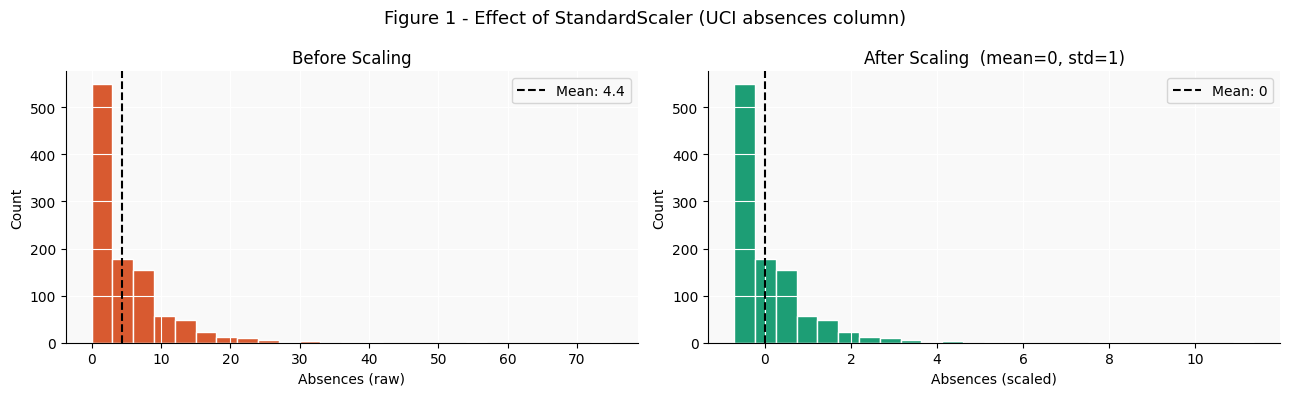

In [ ]:
# Figure 1: Before vs after scaling
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Figure 1 - Effect of StandardScaler (UCI absences column)',
             fontsize=13)

axes[0].hist(uci_full['absences'], bins=25, color=CORAL, edgecolor='white')
axes[0].set_title('Before Scaling')
axes[0].set_xlabel('Absences (raw)')
axes[0].set_ylabel('Count')
axes[0].axvline(uci_full['absences'].mean(), color='black', linestyle='--',
                label='Mean: ' + str(round(uci_full['absences'].mean(), 1)))
axes[0].legend()

axes[1].hist(uci_clf_scaled['absences'], bins=25, color=TEAL, edgecolor='white')
axes[1].set_title('After Scaling  (mean=0, std=1)')
axes[1].set_xlabel('Absences (scaled)')
axes[1].set_ylabel('Count')
axes[1].axvline(0, color='black', linestyle='--', label='Mean: 0')
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/A - PROJECT/data/fig_preprocessing_scaling.png', dpi=150, bbox_inches='tight')
plt.show()

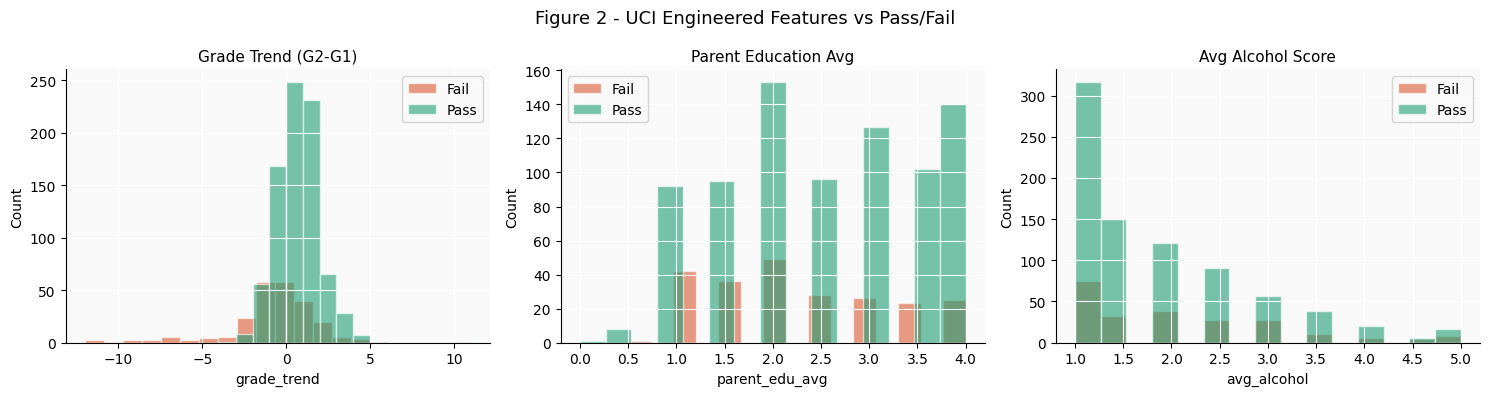

In [ ]:
# Figure 2: Engineered features vs pass/fail
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Figure 2 - UCI Engineered Features vs Pass/Fail',
             fontsize=13)

feats  = ['grade_trend', 'parent_edu_avg', 'avg_alcohol']
titles = ['Grade Trend (G2-G1)', 'Parent Education Avg', 'Avg Alcohol Score']
colors = {0: CORAL, 1: TEAL}
labels = {0: 'Fail', 1: 'Pass'}

for ax, feat, title in zip(axes, feats, titles):
    for val in [0, 1]:
        subset = uci_clf_encoded.loc[uci_clf_encoded['pass_fail'] == val, feat]
        ax.hist(subset, bins=15, alpha=0.6, color=colors[val],
                edgecolor='white', label=labels[val])
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(feat)
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/A - PROJECT/data/fig_engineered_features.png', dpi=150, bbox_inches='tight')
plt.show()

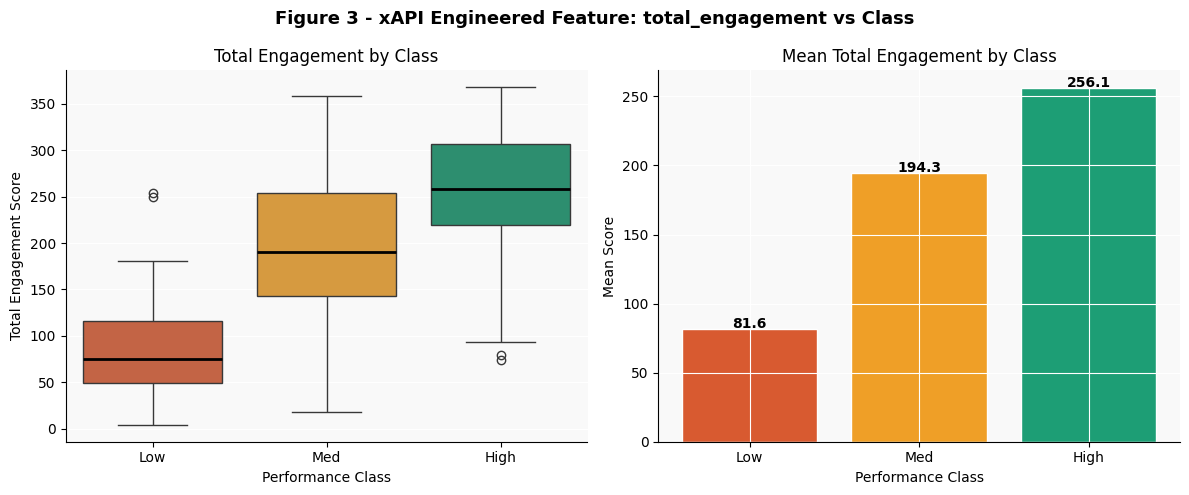

In [ ]:

# Figure 3: xAPI total_engagement vs Class
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Figure 3 - xAPI Engineered Feature: total_engagement vs Class',
             fontsize=13, fontweight='bold')

xapi_plot = xapi_clean.copy()
xapi_plot['Class_label'] = xapi_plot['Class_encoded'].map({0:'Low',1:'Med',2:'High'})
palette = {'Low': CORAL, 'Med': AMBER, 'High': TEAL}

sns.boxplot(data=xapi_plot, x='Class_label', y='total_engagement',
            order=['Low','Med','High'], palette=palette, ax=axes[0],
            medianprops=dict(color='black', linewidth=2))
axes[0].set_title('Total Engagement by Class')
axes[0].set_xlabel('Performance Class')
axes[0].set_ylabel('Total Engagement Score')

# Mean engagement per class as bar chart
eng_means = (xapi_plot.groupby('Class_label')
                      ['total_engagement'].mean()
                      .reindex(['Low','Med','High']))
bars = axes[1].bar(eng_means.index, eng_means.values,
                   color=[CORAL, AMBER, TEAL], edgecolor='white')
for bar, val in zip(bars, eng_means.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 str(round(val, 1)), ha='center', fontweight='bold')
axes[1].set_title('Mean Total Engagement by Class')
axes[1].set_xlabel('Performance Class')
axes[1].set_ylabel('Mean Score')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/A - PROJECT/data/fig_xapi_engagement_feature.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 9 - Summary of All Splits

In [ ]:
print('=' * 62)
print('PREPROCESSING COMPLETE - ALL DATASETS READY')
print('=' * 62)
print()
print('UCI - Classification (predict pass/fail)')
print(f'  Train : {X_train_uci_clf.shape[0]} rows x {X_train_uci_clf.shape[1]} features')
print(f'  Test  : {X_test_uci_clf.shape[0]}  rows x {X_test_uci_clf.shape[1]} features')
print(f'  Target: pass_fail  (0=Fail, 1=Pass)')
print()
print('UCI - Regression (predict G3 grade)')
print(f'  Train : {X_train_uci_reg.shape[0]} rows x {X_train_uci_reg.shape[1]} features')
print(f'  Test  : {X_test_uci_reg.shape[0]}  rows x {X_test_uci_reg.shape[1]} features')
print(f'  Target: G3 (continuous 1-20, G3=0 removed)')
print()
print('UCI - Unsupervised (clustering / Apriori)')
print(f'  Full  : {X_uci_unsup.shape[0]} rows x {X_uci_unsup.shape[1]} features')
print(f'  No split needed for unsupervised learning')
print()
print('xAPI - Classification (predict Low/Med/High)')
print(f'  Train : {X_train_xapi.shape[0]} rows x {X_train_xapi.shape[1]} features')
print(f'  Test  : {X_test_xapi.shape[0]}  rows x {X_test_xapi.shape[1]} features')
print(f'  Target: Class_encoded (0=Low, 1=Med, 2=High)')
print()
print('=' * 62)

PREPROCESSING COMPLETE - ALL DATASETS READY

UCI - Classification (predict pass/fail)
  Train : 835 rows x 44 features
  Test  : 209  rows x 44 features
  Target: pass_fail  (0=Fail, 1=Pass)

UCI - Regression (predict G3 grade)
  Train : 792 rows x 44 features
  Test  : 199  rows x 44 features
  Target: G3 (continuous 1-20, G3=0 removed)

UCI - Unsupervised (clustering / Apriori)
  Full  : 1044 rows x 44 features
  No split needed for unsupervised learning

xAPI - Classification (predict Low/Med/High)
  Train : 384 rows x 27 features
  Test  : 96  rows x 27 features
  Target: Class_encoded (0=Low, 1=Med, 2=High)



---
## Section 10 - Save All Outputs

Saves everything to CSV so Step 4 (Modeling) just loads them directly
— no need to re-run preprocessing.

In [ ]:
# ── UCI Classification ────────────────────────────────────────────────────────
X_train_uci_clf.to_csv('/content/drive/MyDrive/A - PROJECT/data/X_train_uci_clf.csv',   index=False)
X_test_uci_clf.to_csv('/content/drive/MyDrive/A - PROJECT/data/X_test_uci_clf.csv',     index=False)
y_train_uci_clf.to_csv('/content/drive/MyDrive/A - PROJECT/data/y_train_uci_clf.csv',   index=False)
y_test_uci_clf.to_csv('/content/drive/MyDrive/A - PROJECT/data/y_test_uci_clf.csv',     index=False)

# ── UCI Regression ────────────────────────────────────────────────────────────
X_train_uci_reg.to_csv('/content/drive/MyDrive/A - PROJECT/data/X_train_uci_reg.csv',   index=False)
X_test_uci_reg.to_csv('/content/drive/MyDrive/A - PROJECT/data/X_test_uci_reg.csv',     index=False)
y_train_uci_reg.to_csv('/content/drive/MyDrive/A - PROJECT/data/y_train_uci_reg.csv',   index=False)
y_test_uci_reg.to_csv('/content/drive/MyDrive/A - PROJECT/data/y_test_uci_reg.csv',     index=False)

# ── UCI Unsupervised ──────────────────────────────────────────────────────────
X_uci_unsup.to_csv('/content/drive/MyDrive/A - PROJECT/data/X_uci_unsup.csv',           index=False)

# ── xAPI ─────────────────────────────────────────────────────────────────────
X_train_xapi.to_csv('/content/drive/MyDrive/A - PROJECT/data/X_train_xapi.csv',         index=False)
X_test_xapi.to_csv('/content/drive/MyDrive/A - PROJECT/data/X_test_xapi.csv',           index=False)
y_train_xapi.to_csv('/content/drive/MyDrive/A - PROJECT/data/y_train_xapi.csv',         index=False)
y_test_xapi.to_csv('/content/drive/MyDrive/A - PROJECT/data/y_test_xapi.csv',           index=False)

print('All files saved!')
print()
print('UCI Classification  : X_train/test_uci_clf.csv  |  y_train/test_uci_clf.csv')
print('UCI Regression      : X_train/test_uci_reg.csv  |  y_train/test_uci_reg.csv')
print('UCI Unsupervised    : X_uci_unsup.csv')
print('xAPI Classification : X_train/test_xapi.csv     |  y_train/test_xapi.csv')
print()

All files saved!

UCI Classification  : X_train/test_uci_clf.csv  |  y_train/test_uci_clf.csv
UCI Regression      : X_train/test_uci_reg.csv  |  y_train/test_uci_reg.csv
UCI Unsupervised    : X_uci_unsup.csv
xAPI Classification : X_train/test_xapi.csv     |  y_train/test_xapi.csv



In [ ]:
# ── Extra files needed by Step 5 (unsupervised) ──────────────────────────────

# 1. xAPI full feature matrix (all 480 rows, no split)
X_xapi_unsup = xapi_scaled.drop(columns=['Class_encoded'])
X_xapi_unsup.to_csv('/content/drive/MyDrive/A - PROJECT/data/X_xapi_unsup.csv', index=False)

# 2. Raw UCI merged unscaled — needed for Apriori binning
uci_full.to_csv('/content/drive/MyDrive/A - PROJECT/data/uci_raw_full.csv', index=False)

# 3. UCI labels for cluster interpretation
uci_clf_scaled[['pass_fail', 'G3', 'absences']].to_csv('/content/drive/MyDrive/A - PROJECT/data/uci_labels.csv', index=False)

# 4. xAPI labels for cluster interpretation
xapi_scaled[['Class_encoded']].to_csv('/content/drive/MyDrive/A - PROJECT/data/xapi_labels.csv', index=False)

# 5. xAPI raw — needed for Apriori binning (original text values)
xapi.to_csv('/content/drive/MyDrive/A - PROJECT/data/xAPI-Edu-Data.csv', index=False)

print('Saved: X_xapi_unsup.csv')
print('Saved: uci_raw_full.csv')
print('Saved: uci_labels.csv')
print('Saved: xapi_labels.csv')
print('Saved: xAPI-Edu-Data.csv')
print('All Step 5 files ready.')

Saved: X_xapi_unsup.csv
Saved: uci_raw_full.csv
Saved: uci_labels.csv
Saved: xapi_labels.csv
Saved: xAPI-Edu-Data.csv
All Step 5 files ready.
